# Panel 1 C D

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# to save the figures in adobe friendly fashion
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

In [ ]:
# Set working directory cramino output
os.chdir("/cramino/2025_cramino")

file_paths = glob.glob("**/*.txt", recursive=True)

def process_file(file_path):
    file_data = pd.read_csv(file_path, sep="\t", header=None, names=["keys", "values"], dtype=str)
    
    file_data["keys"] = file_data["keys"].str.strip()
    file_data["values"] = file_data["values"].str.strip()
    file_name = os.path.splitext(os.path.basename(file_path))[0]
    file_data["File"] = file_name
    file_data = file_data[(file_data["keys"] != "") & (file_data["values"] != "")]
    return file_data

# Process each file and combine
combined_data = pd.concat([process_file(fp) for fp in file_paths], ignore_index=True)
combined_data = combined_data.pivot(index="File", columns="keys", values="values").reset_index()
columns_to_remove = ["Creation time", "Path", "File name"] # remove unneeded columns
combined_data = combined_data.drop(columns=[col for col in columns_to_remove if col in combined_data.columns])

numeric_cols = [
    "Number of reads", "Yield [Gb]", "Mean coverage", "N50",
    "Median length", "Mean length", "Median identity", "Mean identity"
]
for col in numeric_cols:
    if col in combined_data.columns:
        combined_data[col] = pd.to_numeric(combined_data[col], errors="coerce")

combined_data["sample_name"] = combined_data["File"].str.replace("_cramino", "", regex=False)


In [ ]:
metadata = pd.read_csv('wgs_nanowgs_versions.csv'). # change path as necessary
metadata = metadata.rename(columns={"Sample":"sample_name"})
metadata

In [6]:
df = combined_data.merge(metadata, on = 'sample_name')
df

,File,% from total reads,Mean coverage,Mean identity,Mean length,Median identity,Median length,Modal identity,N50,N75,...,clair3,minimap2,samtools_pre_cram,kit,method,model_basecalling,mod_model_basecalling,dorado_version,basecaller,guppy_version
0,ASA_001B,100.00,14.62,98.32,14824,99.21,5994.0,99.5,36083,22451,...,v1.0.9-rerio,2.28-r1209,1.20,SQK-LSK114,Native,dna_r10.4.1_e8.2_400bps_sup@v5.0.0,5mC_5hmC,0.7.0+71cc744,Dorado,NaN
1,ASA_002B,100.00,20.78,97.78,12893,98.46,4439.0,99.0,33822,19458,...,v1.0.9-rerio,2.24-r1122,1.17,SQK-LSK114,Fiber,dna_r10.4.1_e8.2_400bps_sup@v4.1.0-finetuned,"6mA,5mC",0.3.2+d8660a3,Dorado,NaN
2,ASA_003B,100.00,15.11,94.41,3091,96.05,1985.0,98.0,5698,3298,...,v1.0.9-rerio,2.24-r1122,1.14,SQK-LSK110,Native,dna_r9.4.1_450bps_sup_prom.cfg,NaN,NaN,Guppy,6.0.1+652ffd1
3,ASA_004B,100.00,13.74,98.05,9852,98.93,2994.0,99.5,28987,14545,...,v1.0.9-rerio,2.24-r1122,1.17,SQK-LSK114,Native,dna_r10.4.1_e8.2_400bps_sup@v4.2.0,5mCG_5hmCG,0.3.2+d8660a3,Dorado,NaN
4,ASA_005B,100.00,28.99,98.05,2887,98.72,1446.0,99.2,5820,2554,...,v1.0.9-rerio,2.24-r1122,1.17,SQK-LSK114,Native,dna_r10.4.1_e8.2_400bps_sup@v4.1.0,5mCG_5hmCG,0.2.4+3fc2b0f,Dorado,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183,ASA_186B,100.00,27.62,98.15,4530,98.88,1483.0,99.5,14384,4866,...,v1.0.9-rerio,2.24-r1122,1.17,SQK-LSK114,Native,dna_r10.4.1_e8.2_400bps_sup@v4.2.0,5mCG_5hmCG,0.3.2+d8660a3,Dorado,NaN
184,ASA_187B,100.00,37.68,98.44,6648,99.04,1928.0,99.5,24814,8305,...,v1.0.9-rerio,2.24-r1122,1.17,SQK-LSK114,Native,dna_r10.4.1_e8.2_400bps_sup@v4.2.0,5mCG_5hmCG,0.3.2+d8660a3,Dorado,NaN
185,ASA_188B,100.00,29.54,98.20,5208,98.91,1448.0,99.5,17421,6881,...,v1.0.9-rerio,2.24-r1122,1.17,SQK-LSK114,Native,dna_r10.4.1_e8.2_400bps_sup@v4.2.0,5mCG_5hmCG,0.3.2+d8660a3,Dorado,NaN
186,ASA_189B,100.00,30.36,98.40,3124,99.07,1330.0,99.5,7522,2866,...,v1.0.9-rerio,2.24-r1122,1.17,SQK-LSK114,Native,dna_r10.4.1_e8.2_400bps_sup@v4.2.0,5mCG_5hmCG,0.3.2+d8660a3,Dorado,NaN


In [11]:
df['Mean coverage'].mean()	

27.49409574468085

In [12]:
df['Mean length'].mean()	

8219.31914893617

In [10]:
df['N50'].mean()	

22900.93085106383

/tmp/ipykernel_254059/2393295422.py:10: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(x='kit', y='Mean coverage', hue='method', data=df, dodge=True, jitter=0.15, color='black', size=2, alpha=0.7, ax=axes[0])
/tmp/ipykernel_254059/2393295422.py:29: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0].set_xticklabels(new_labels)
/tmp/ipykernel_254059/2393295422.py:34: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(x='kit', y='Mean length', hue='method', data=df, dodge=True, jitter=0.15, color='black', size=2, alpha=0.7, ax=axes[1])
/tmp/ipykernel_254059/2393295422.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[1].set_xticklabels(new_labels)


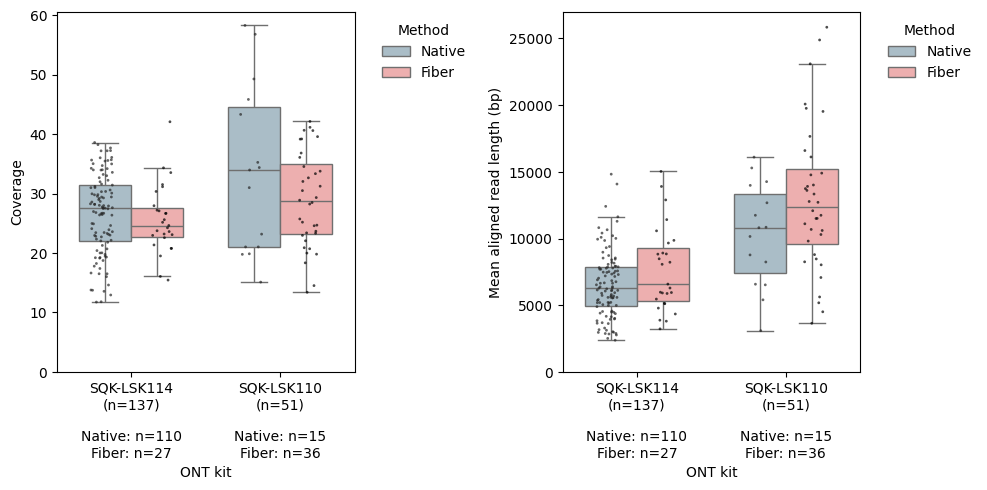

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(10, 5))  

custom_palette = {'Native': '#A5BFCC', 'Fiber': '#F7A5A5'}

# First plot: Mean coverage
sns.boxplot(x='kit', y='Mean coverage', hue='method', data=df, showfliers=False, palette=custom_palette, width=0.7, ax=axes[0])
sns.stripplot(x='kit', y='Mean coverage', hue='method', data=df, dodge=True, jitter=0.15, color='black', size=2, alpha=0.7, ax=axes[0])

axes[0].set_title('')
axes[0].set_xlabel('ONT kit')
axes[0].set_ylabel('Coverage')

handles, labels = axes[0].get_legend_handles_labels()
n_kit = df['kit'].nunique()
axes[0].legend(handles[:n_kit], labels[:n_kit], title='Method', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

methods = df['method'].unique()
kits = df['kit'].unique()
new_labels = []
for kit in kits:
    total_n = df[df['kit'] == kit].shape[0]
    method_counts = [df[(df['method'] == met) & (df['kit'] == kit)].shape[0] for met in methods]
    label = f"{kit}\n(n={total_n})\n\n" + "\n".join([f"{met}: n={count}" for met, count in zip(methods, method_counts)])
    new_labels.append(label)

axes[0].set_xticklabels(new_labels)
axes[0].set_ylim(0)

# Second plot: Mean length
sns.boxplot(x='kit', y='Mean length', hue='method', data=df, palette=custom_palette, showfliers=False, width=0.7, ax=axes[1])
sns.stripplot(x='kit', y='Mean length', hue='method', data=df, dodge=True, jitter=0.15, color='black', size=2, alpha=0.7, ax=axes[1])

axes[1].set_title('')
axes[1].set_xlabel('ONT kit')
axes[1].set_ylabel('Mean aligned read length (bp)')

handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles[:n_kit], labels[:n_kit], title='Method', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

axes[1].set_xticklabels(new_labels)
axes[1].set_ylim(0)

plt.tight_layout()
plt.savefig('/figures/boxplot_coverage_length_kit.pdf', format='pdf', bbox_inches='tight')
plt.show()